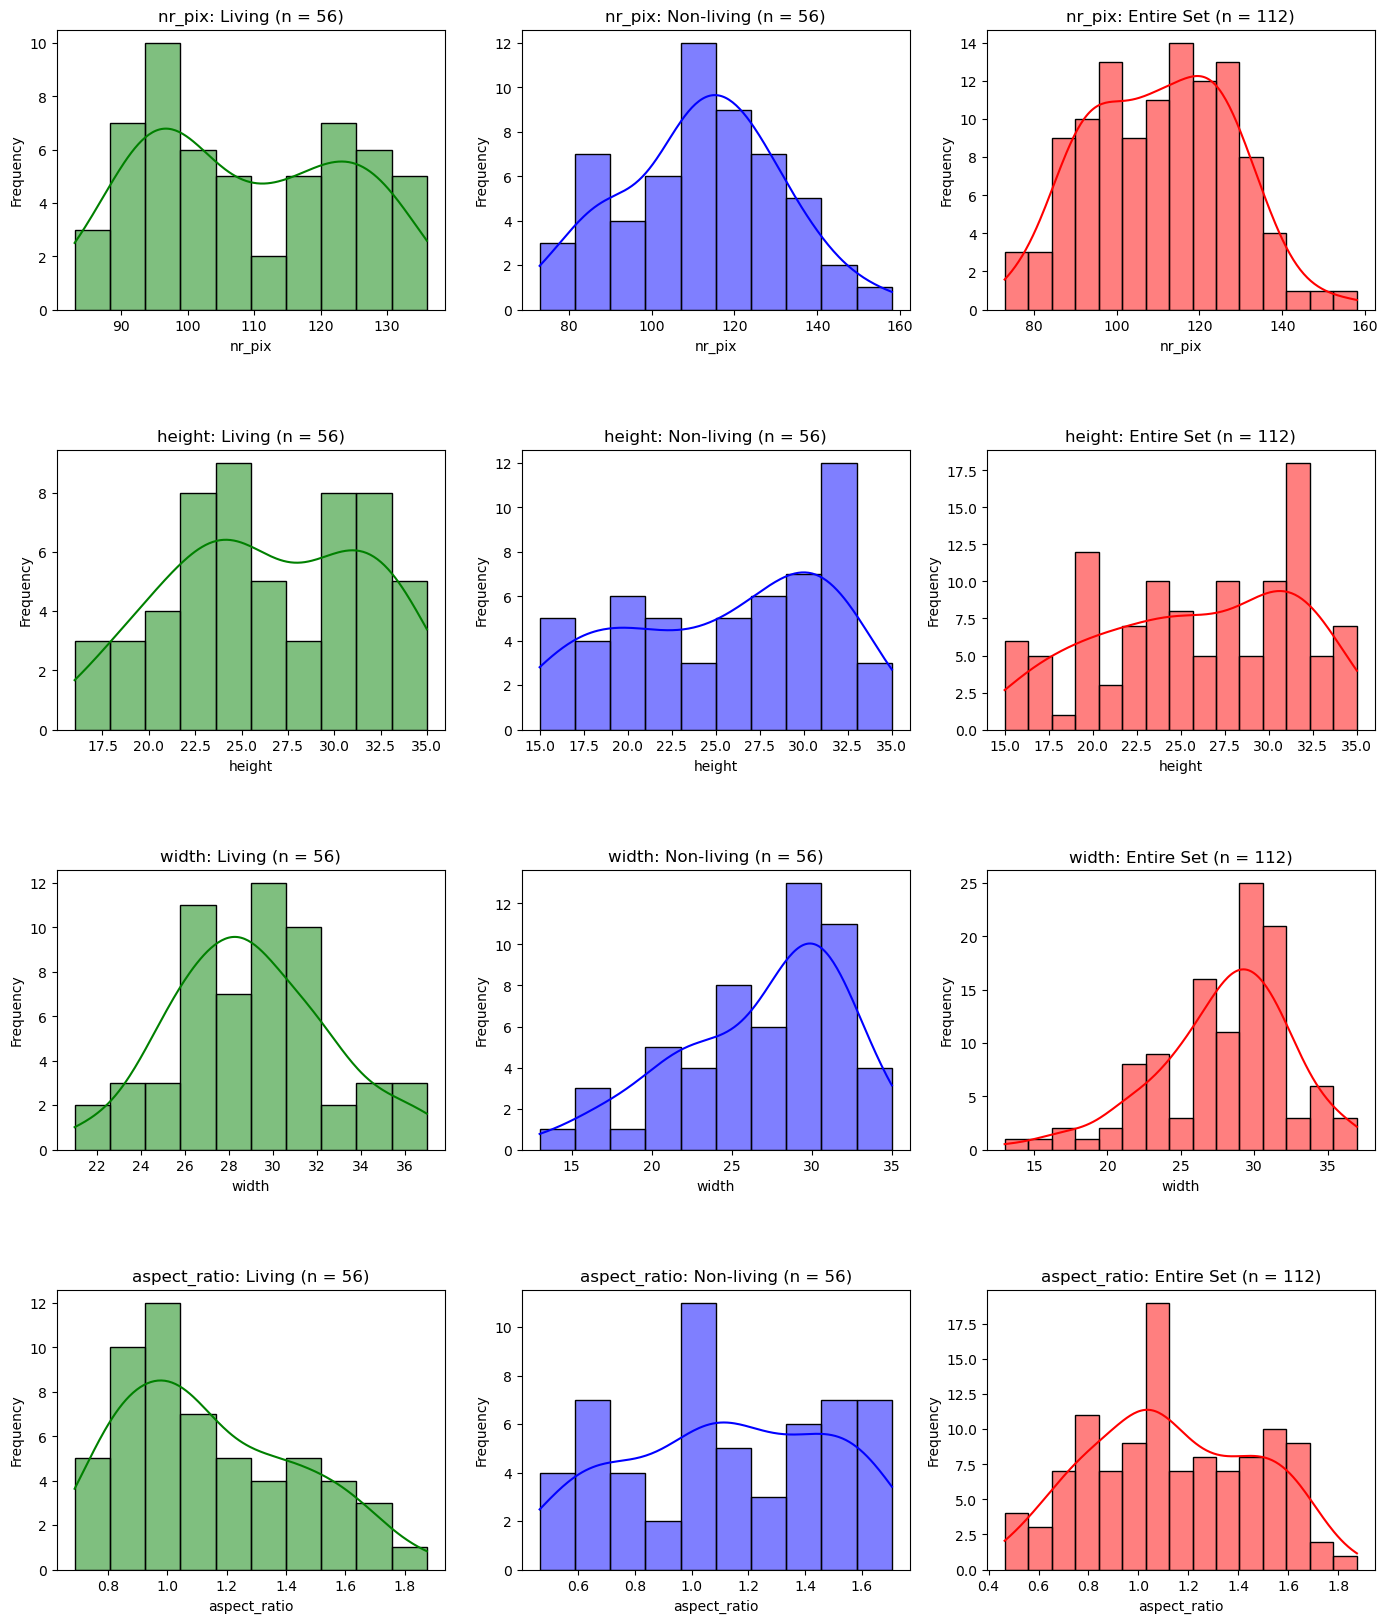

In [1]:
#3.1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Fetch and load data set
student_ID = '40443014'
data_set = pd.read_csv(f"{student_ID}_features.csv")

#Define object categories
living_objects = ['banana', 'cherry', 'lemon', 'tree']
non_living_objects = ['envelope','golfclub','pencil','wineglass']

#Define the features
plot_features = ['nr_pix', 'height', 'width', 'aspect_ratio']

#Split the data (separate into smaller tables)
data_set['is_living'] = data_set['Object'].isin(living_objects).astype(int)
living_data = data_set[data_set['is_living'] == 1]
non_living_data = data_set[data_set['is_living'] == 0]

#Creating a 4 features x3 columns grid
fig, axes = plt.subplots(4, 3, figsize = (17, 20))
fig.subplots_adjust(hspace=0.5)

for i, feature in enumerate(plot_features):

    #Living 
    sns.histplot(living_data[feature], bins=10, color='Green', edgecolor='Black', kde=True, ax=axes[i,0])
    axes[i, 0].set_title(f"{feature}: Living (n = {len(living_data)})")
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel('Frequency')

    #Non-Living
    sns.histplot(non_living_data[feature], bins=10, color='Blue', edgecolor='Black', kde=True, ax=axes[i,1])
    axes[i, 1].set_title(f"{feature}: Non-living (n = {len(non_living_data)})")
    axes[i, 1].set_xlabel(feature)
    axes[i, 1].set_ylabel('Frequency')

    #Entire
    sns.histplot(data_set[feature], bins=15, color='Red', edgecolor='Black', kde=True, ax=axes[i,2])
    axes[i, 2].set_title(f"{feature}: Entire Set (n = {len(data_set)})")
    axes[i, 2].set_xlabel(feature)
    axes[i, 2].set_ylabel('Frequency')

plt.show()

<h1> 3.1 Code breakdown </h1>

1. Libraries are imported, objects are separated and defined and features are defined.

2. Separate living objects into a new column in the table called is_living. 'isin' checks every row Object name to see if its in the living list returning a boolean and 'astype(int)' turns the 'True' and 'False' variables into 1 and 0. Using these '1's and '0's two smaller tables are created one with all "living" '1's and the other with all non-living '0's.

3. Blank canvases created for graphs with a 4 row by 3 column grid of empty graphs created. figure specified to a size of 17 inches wide by 20 inches tall. Empty height space added as well so text and titles dont overlap.

4. Loop created that goes through all plot features one by one.

5. Within the loop, the living, non-living and entire set graphs are created for each feature. Histogram is created with 10 bars for both living and non-living and 15 bars for entire (has a bigger total so more data to represent). Each set is given a specific colour (went with RGB for strong contrast) and black outlines to make each histogram distinct. A smooth density curve is then added by setting KDE to True. Each graph targets the row that the loop's 'i' is currently on and the columns are added (living = 0, non-living = 1 and entire = 2). Title is then set and amount of rows counted and displayed. Lastly x and y axes are labeled with the feature and its frequency.

6. 'plt.show()' renders all 12 graphs.

Estimated Sample Mean: 110.46
Sample Variance: 294.45
Sample Standard Deviation: 17.16



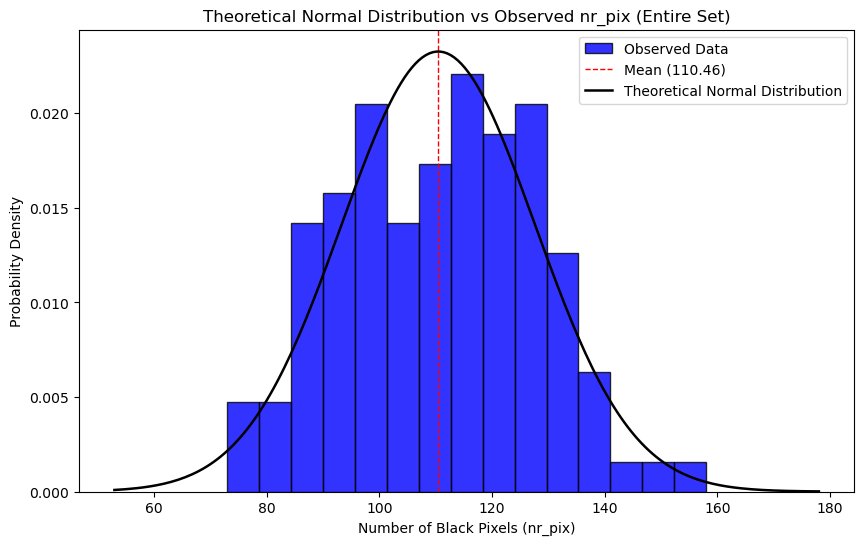

In [2]:
#3.2
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt

#Fetch and load data set
student_ID = '40443014'
data_set = pd.read_csv(f"{student_ID}_features.csv")

#Estimate sample mean and sample variance for all items 
mean = data_set['nr_pix'].mean()
var = data_set['nr_pix'].var(ddof=1)
stdev = data_set['nr_pix'].std(ddof=1)

print(f"Estimated Sample Mean: {mean:.2f}")
print(f"Sample Variance: {var:.2f}")
print(f"Sample Standard Deviation: {stdev:.2f}\n")

#Plot histogram and estimated normal distribution
plt.figure(figsize=(10,6))
plt.hist(data_set['nr_pix'], bins=15, density=True, color='Blue',edgecolor='Black', alpha=0.8, label='Observed Data')

#Estimated Normal curve
x_min = data_set['nr_pix'].min()-20
x_max = data_set['nr_pix'].max() + 20
x = np.linspace(x_min, x_max, 200)

#Calculate Y-value (Probability Density)
y = stats.norm.pdf(x, mean, stdev)

#show bell curve and where mean is
plt.axvline(mean, color='Red', linestyle='dashed', linewidth=1, label=f'Mean ({mean:.2f})')
plt.plot(x,y, color='Black', linewidth=1.8, label="Theoretical Normal Distribution")

#Titles and legend
plt.title('Theoretical Normal Distribution vs Observed nr_pix (Entire Set)')
plt.xlabel('Number of Black Pixels (nr_pix)')
plt.ylabel('Probability Density')
plt.legend()

plt.show()

<h1> 3.2 Code Breakdown</h1>

1. Libraries are imported and the dataset is fetched and loaded.

2. Sample mean, variance and standard deviation are calculated using the pandas library. For variance and standard deviation we attach the "ddof=1" to highlight dividing by (n-1) which is required when estimating using a smaller sample. Results are then printed.

3. A blank canvas of 10 inches wide and 6 inches high is created and used for histogram. Histogram is created using the nr_pix data set. The histogram is made with 15 bars, coloured blue with slight transparency. Density = True normalises the histogram so the total area under the bars equals 1.0 which is necessary to correctly overlay the bell curve.

4. The code gets minimum and maximum pixel count in dataset and adds a 20-pixel padding (don't want graph cutting off abruptly). 'x' will be a list of 200 evenly spaced numbers between the minimum and maximum and will act as the x-axis for drawing the bell curve.

5. 'y' will take the pdf function with the estimated sample mean and standard deviation and will calculate the probability density for all 200 points of 'x'.

6. plt.axvline plots a straight red line at exactly the 'mean'.

7. plt.plot will generate the continuous theoretical bell curve by plotting the y against the 200 data points of x.

8. Titles are added to the graph, x-axis and y-axis and final graph is rendered.




Upper 5% Cut-off: 138.69 pixels

Images in top 5%: 
      Object  Index  nr_pix
63  envelope      8   147.0
65  envelope     10   146.0
66  envelope     11   158.0


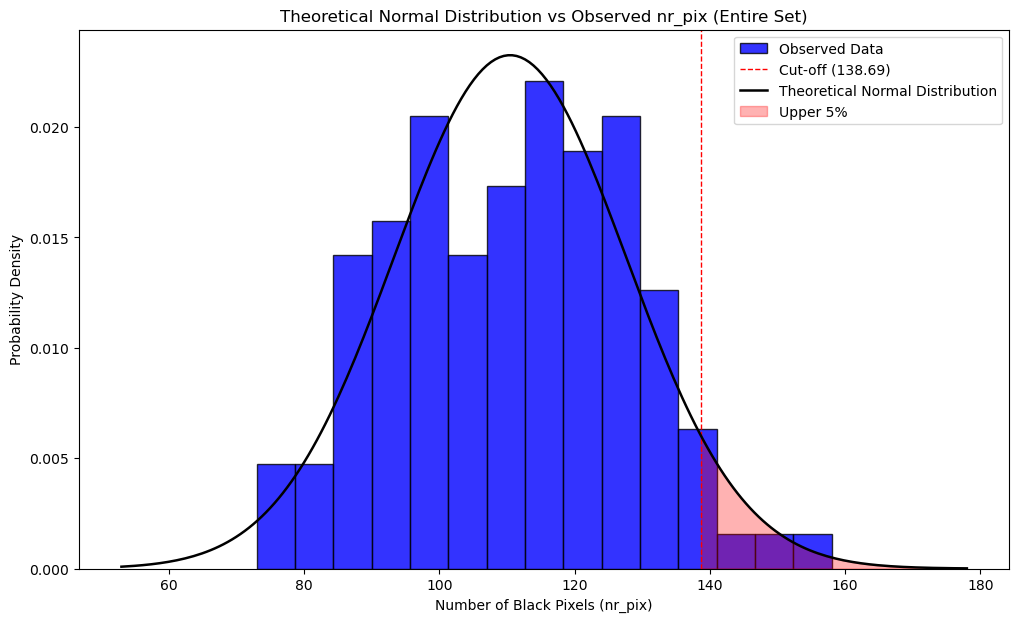

In [3]:
#3.3
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt

#Fetch and load data set
student_ID = '40443014'
data_set = pd.read_csv(f"{student_ID}_features.csv")

#Estimate sample mean and standard deviation for all items 
mean = data_set['nr_pix'].mean()
stdev = data_set['nr_pix'].std(ddof=1)

#Calculating percentile for the normal distribution
cut_off = stats.norm.ppf(0.95, loc= mean, scale=stdev)

print(f"Upper 5% Cut-off: {cut_off:.2f} pixels\n")

#Images above cut off
upper_5 = data_set[data_set['nr_pix'] > cut_off]
print("Images in top 5%: ")
print(upper_5[['Object', 'Index', 'nr_pix']])

#Estimated Normal curve
x_min = data_set['nr_pix'].min()-20
x_max = data_set['nr_pix'].max() + 20
x = np.linspace(x_min, x_max, 200)

#Calculate Y-value (Probability Density)
y = stats.norm.pdf(x, mean, stdev)

#cut off shaded
x_shaded = np.linspace(cut_off, x_max, 200)
y_shaded = stats.norm.pdf(x_shaded, mean, stdev)

#Graph
plt.figure(figsize=(12,7))
plt.hist(data_set['nr_pix'], bins=15, density=True, color='Blue',edgecolor='Black', alpha=0.8, label='Observed Data')
plt.axvline(cut_off, color='Red', linestyle='dashed', linewidth=1, label=f'Cut-off ({cut_off:.2f})')
plt.plot(x,y, color='Black', linewidth=1.8, label="Theoretical Normal Distribution")
plt.fill_between(x_shaded,y_shaded, color='red', alpha=0.3, label='Upper 5%')

plt.title('Theoretical Normal Distribution vs Observed nr_pix (Entire Set)')
plt.xlabel('Number of Black Pixels (nr_pix)')
plt.ylabel('Probability Density')
plt.legend()

plt.show()

<h1> 3.3 Code Breakdown</h1>

1. Libraries are imported and the dataset is fetched and loaded.

2. Sample mean and standard deviation are calculated using pandas library.

3. The 95% cut-off is calculated using scipy library's ppf function with the value being 0.95 (representing the lower 95% of the graph), and using the estimated mean and standard deviation to get the number of pixels needed for an image to be in the upper 5% of the theoretical distribution. The result is printed for use in the documentation.

4. Images with pixel counts greater than the cut-off are added to the upper_5 variable and printed for later use in the documentation.

5. (Takes from Section 3.2) <p>The code gets the minimum and the maximum pixel count in the dataset and adds a 20-pixel padding (so we don't have the graph cutting off abruptly). 'x' will be a list of 200 evenly spaced numbers between the minimum and maximum and will act as the x-axis for drawing the bell curve. 'y' will take the pdf function with the estimated sample mean and standard deviation and will calculate the probability density for all 200 points of 'x'.</p>

6. Using the same code but changing the starting point to the cut-off, a new range is created so that a red shade can be added under the curve to highlight the upper 5% tail.

7. Most graph creation was copied from section 3.2 including the building of the graph with the data and the bell curve. The only thing added was the red shaded area for the upper 5%. plt.fill_between took the shaded range for x and y and created a 30% transparency red block under the bell curve.


Comparison of means (Living vs Non Living)
                 Non-Living      Living
nr_pix           112.053571  108.875000
rows_with_1        2.285714    1.017857
cols_with_1        0.767857    2.535714
rows_with_2        7.910714    8.946429
cols_with_2        5.000000    6.785714
rows_with_3p      16.267857   17.517857
cols_with_3p      22.107143   20.660714
height            25.464286   26.482143
width             26.875000   28.982143
aspect_ratio       1.127941    1.144519
maxrow            15.678571   12.285714
maxcol            12.375000    9.017857
connected_areas    1.339286    1.250000
eyes               1.250000    0.750000
hollowness         1.147813    2.240312
custom             0.177774    0.146417  


T-Test Results (Living vs Non-Living)
       Features  T-Statistic  P-Value                                  Evidence
         maxcol    -4.433397 0.000034      Strong (Reject H0 / Null Hypothesis)
     hollowness     4.235063 0.000051      Strong (Reject H0 / Null Hypothe

C:\Users\Skump\AppData\Local\Temp\ipykernel_24876\1166765896.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='is_living', y='hollowness', data=data_set, palette ='Set2')
C:\Users\Skump\AppData\Local\Temp\ipykernel_24876\1166765896.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-Living', 'Living'])
C:\Users\Skump\AppData\Local\Temp\ipykernel_24876\1166765896.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='is_living', y='maxcol', data=data_set, palette ='Set2')
C:\Users\Skump\AppData\Local\Temp\ipykernel_24876\1166765896.py:65: UserWarn

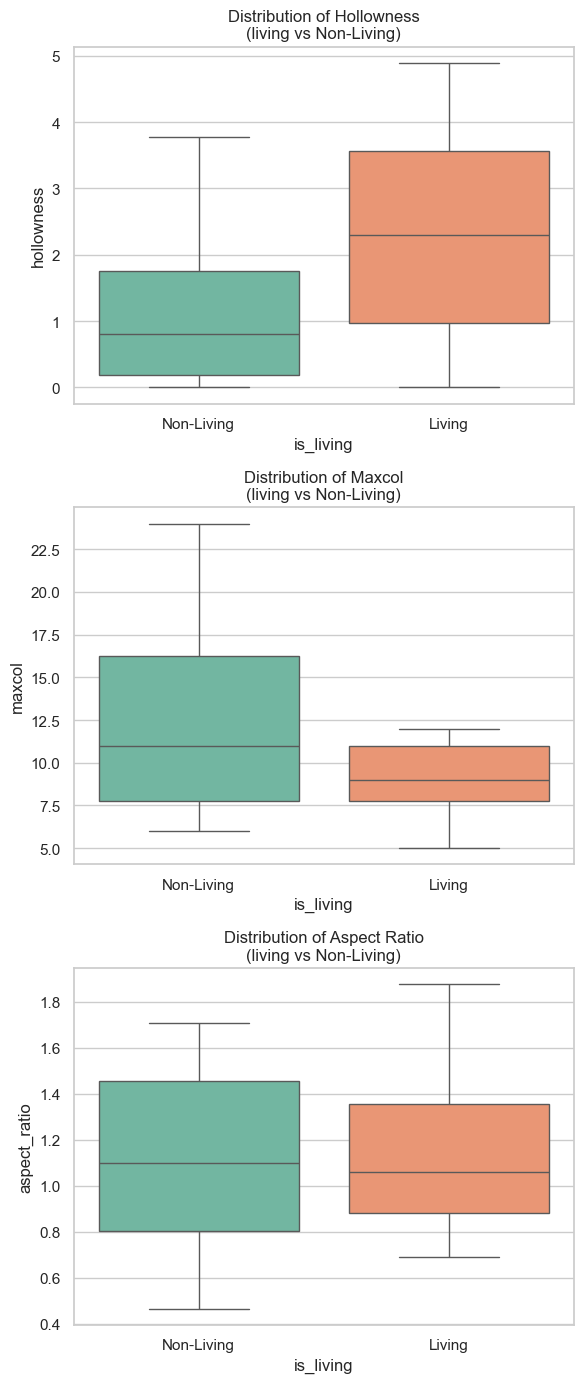

In [4]:
#3.4

import pandas as pd
import scipy.stats as stats 
import seaborn as sns
import matplotlib.pyplot as plt

#Fetch and load data set
student_ID = '40443014'
data_set = pd.read_csv(f"{student_ID}_features.csv")

#Define object categories
living_objects = ['banana', 'cherry', 'lemon', 'tree']
non_living_objects = ['envelope','golfclub','pencil','wineglass']

#Split the data (separate into smaller tables)
data_set['is_living'] = data_set['Object'].isin(living_objects).astype(int)
living_data = data_set[data_set['is_living'] == 1]
non_living_data = data_set[data_set['is_living'] == 0]

#Mean of subsets and their features
categories_mean = data_set.drop(columns=['Object', 'Index']).groupby("is_living").mean()

categories_mean.index = ['Non-Living', "Living"]

print("Comparison of means (Living vs Non Living)")
print(f"{categories_mean.T}  \n\n")

#Defines Significance Level
alpha = 0.05

#Run T-Tests
all_features = data_set.columns.drop(['Object','Index','is_living'])

t_test_results = []

for f in all_features:
    #T-test
    t_test, p_val = stats.ttest_ind(living_data[f], non_living_data[f], equal_var=False)

    #Strong vs Weak Evidence (H0 = There is no difference between living and non living drawings in specific feature)
    null_hypothesis_evidence = "Strong (Reject H0 / Null Hypothesis)" if p_val < alpha else "Weak (Fail to Reject H0/ Null Hypothesis)"

    t_test_results.append({'Features':f, 'T-Statistic': t_test, 'P-Value': p_val,'Evidence': null_hypothesis_evidence})

#Display results
t_test_results = pd.DataFrame(t_test_results).sort_values(by='P-Value')
print("T-Test Results (Living vs Non-Living)")
print(t_test_results.to_string(index=False))

#Box plots
#set style and figure with subplots
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(6, 14))

#Hollowness
sns.boxplot(ax=axes[0], x='is_living', y='hollowness', data=data_set, palette ='Set2')
axes[0].set_title('Distribution of Hollowness\n(living vs Non-Living)')
axes[0].set_xticklabels(['Non-Living', 'Living'])

#Maxcol
sns.boxplot(ax=axes[1], x='is_living', y='maxcol', data=data_set, palette ='Set2')
axes[1].set_title('Distribution of Maxcol\n(living vs Non-Living)')
axes[1].set_xticklabels(['Non-Living', 'Living'])
#Aspect Ratio
sns.boxplot(ax=axes[2], x='is_living', y='aspect_ratio', data=data_set, palette ='Set2')
axes[2].set_title('Distribution of Aspect Ratio\n(living vs Non-Living)')
axes[2].set_xticklabels(['Non-Living', 'Living'])

plt.tight_layout()
plt.show()

<h1> 3.4 Code Breakdown</h1>

1. Libraries are imported and the dataset is fetched and loaded.

2. Separate living objects into a new column in the table called is_living. 'isin' checks every row's Object name to see if its in the living list returning a boolean and 'astype(int)' turns the 'True' and 'False' variables into 1 and 0. Using these '1's and '0's two smaller tables are created one with all "living" '1's and the other with all non-living '0's.

3. For the mean, a temporary version of data is created without the 'Object' and 'Index' column. Data is then split into two piles (living and non-living) and the average is calcuated for each feature. Rows are then renamed to Living and Non-Living, table is transposed (so that features are the rows and catagories become the columns) and printed.

4. The significance level is set to alpha = 0.05, establishing the threshold for statistical significance.

5. In all features, 'Object', 'Index' and 'is_living' are dropped as they're non-numeric text columns (makes sure maths functions don't crash code).

6. For each feature in all_features, the function 'stats.ttest_ind' gathers both the result of the t-test and the P-Value of each test.

7. If the p value is less than the significance level then the Null hypothesis is rejected as there is strong evidence to suggest a difference between the two groups. If p is greater then we fail to reject on the basis of no convincing evidence. These results are stored into the variable 'null_hypothesis_evidence'.

8. Results of all these calculations are appended to t_test_results.

9. All results in 't_test_results' are sorted by p_value from smallest to largest (easier format to read).

10. All results are printed.

11. For visuals in documentation boxplots are created. First a white background is applied using seaborn. Then a grid of 3 rows and 1 column (each being 14 by 6 in dimension). For first boxplot, its axes its attached to a subplot index(axes[0]), is living catagories is applied on horizontal axis and feature (in this case hollowness) is applied on vertical axis. Title is added and names of categories are applied (over the 0 and 1 they had been replabeled to) the plot is printed to fit the dimensions. This is repeated for all required features.

Correlation Coefficient
                nr_pix    height     width  aspect_ratio  hollowness
nr_pix        1.000000 -0.140591  0.737550      0.481540    0.109290
height       -0.140591  1.000000 -0.148336     -0.871997   -0.272333
width         0.737550 -0.148336  1.000000      0.586768    0.136306
aspect_ratio  0.481540 -0.871997  0.586768      1.000000    0.317272
hollowness    0.109290 -0.272333  0.136306      0.317272    1.000000


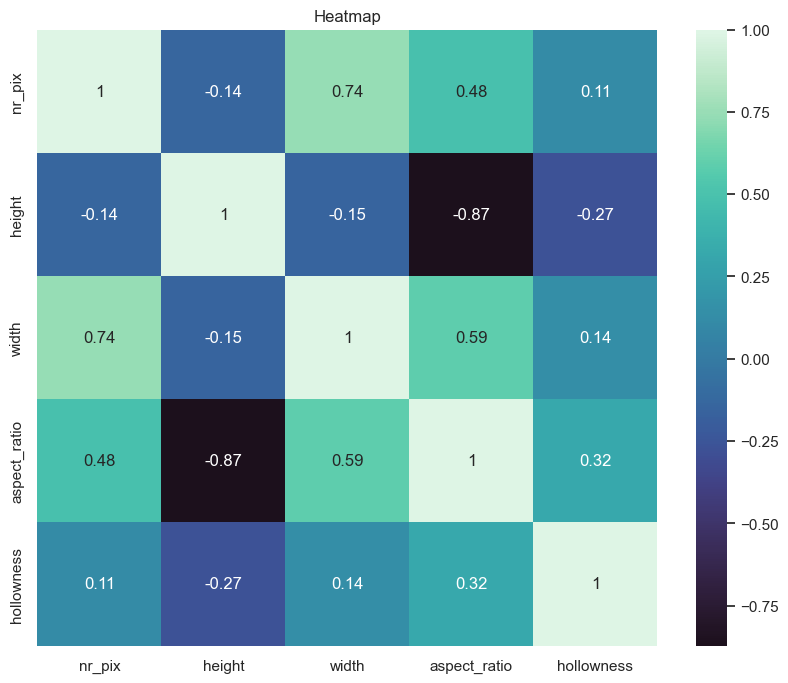

Inference for Correlation Coefficient
nr_pix and height
Correlation Coeffiecient =  -0.141
P-Value = 0.1393| So: Not Significant (Fail to reject H0/ Null Hypothesis) 

nr_pix and width
Correlation Coeffiecient =  0.738
P-Value = 0.0000| So: Significant (Reject h0/ Null Hypothesis) 

nr_pix and aspect_ratio
Correlation Coeffiecient =  0.482
P-Value = 0.0000| So: Significant (Reject h0/ Null Hypothesis) 

nr_pix and hollowness
Correlation Coeffiecient =  0.109
P-Value = 0.2513| So: Not Significant (Fail to reject H0/ Null Hypothesis) 

height and width
Correlation Coeffiecient =  -0.148
P-Value = 0.1186| So: Not Significant (Fail to reject H0/ Null Hypothesis) 

height and aspect_ratio
Correlation Coeffiecient =  -0.872
P-Value = 0.0000| So: Significant (Reject h0/ Null Hypothesis) 

height and hollowness
Correlation Coeffiecient =  -0.272
P-Value = 0.0037| So: Significant (Reject h0/ Null Hypothesis) 

width and aspect_ratio
Correlation Coeffiecient =  0.587
P-Value = 0.0000| So: Signif

<Figure size 1000x800 with 0 Axes>

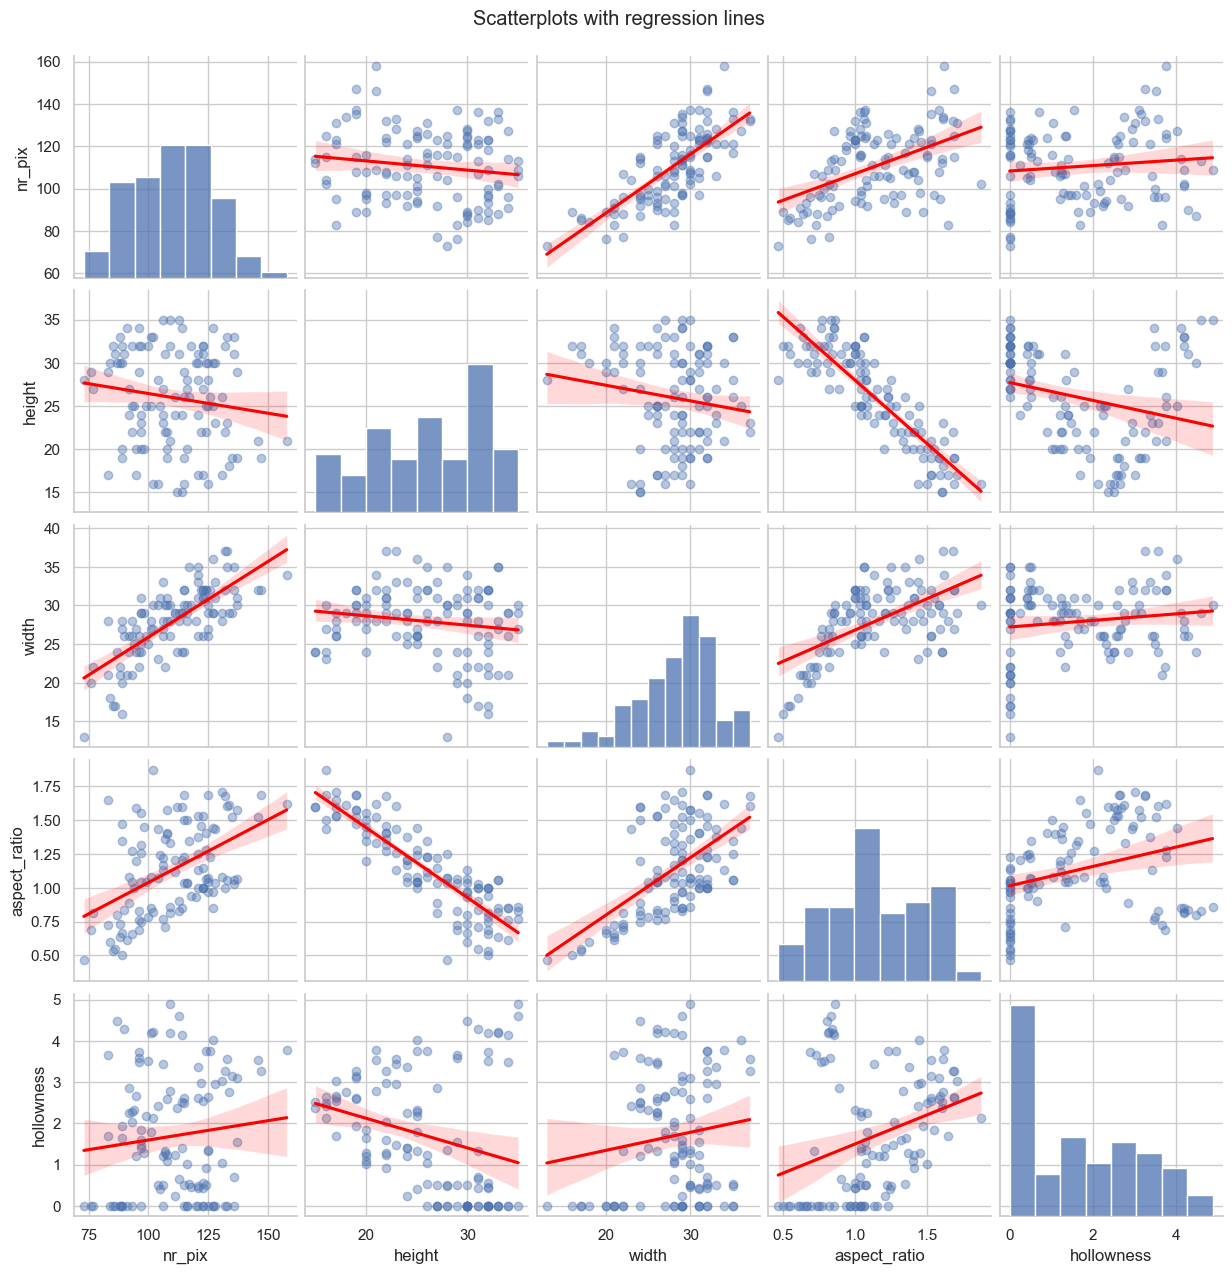

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt

#Fetch and load data set
student_ID = '40443014'
data_set = pd.read_csv(f"{student_ID}_features.csv")

#5 features
features = ['nr_pix', 'height', 'width', 'aspect_ratio', 'hollowness']
subset = data_set[features]

#Calculate Pearsons Correlation Coefficient
corr_co = subset.corr(method='pearson')

#Print Correlation Coefficient matrix
print("Correlation Coefficient")
print(corr_co)

#Printing Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_co, annot=True, cmap='mako', center=0)
plt.title('Heatmap')
plt.show()

#Inference Test
print("Inference for Correlation Coefficient")
alpha = 0.05

#Loop compares all features to each other
for i in range(len(features)):
    for j in range(i+1, len(features)):
        feature_1 = features[i]
        feature_2 = features[j]

        #Calcuate correlation and p-value for pearson inference
        corr_co, p_val = stats.pearsonr(subset[feature_1], subset[feature_2])

        #H0 = No linear relationship between the two variables population
        null_hypothesis_evidence = "Significant (Reject h0/ Null Hypothesis)" if p_val < alpha else "Not Significant (Fail to reject H0/ Null Hypothesis)"

        #Print result for two features population relationship
        print(f"{feature_1} and {feature_2}")
        print(f"Correlation Coeffiecient =  {corr_co:.3f}")
        print(f"P-Value = {p_val:.4f}| So: {null_hypothesis_evidence} \n")

#Printing ScatterPlot w/ regression lines
plt.figure(figsize=(10,8))
sns.pairplot(subset, kind='reg', plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.4}})
plt.suptitle('Scatterplots with regression lines', y =1.02)
plt.show()

<h1> 3.5 Code Breakdown</h1>

1. Libraries are imported and the dataset is fetched and loaded.

2. A list of specified features is created and stored as a dataframe in subset.

3. Pearson's Correlation Coefficient is calculated for every possible pair of the 5 features creating a 5x5 matrix. In each of these pairs both strength and direction of relationship are measured.

4. Numerical data from each relationship is then printed. 

5. Using data from the calculated correlation coefficient, a heatmap is created. The heatmap uses a dark blue to green spectrum for visual representation and includes all numeric values for deeper understanding.

6. Inference Testing begins with alpha being set at 0.05 significance level representing a 95% confidence level for the statistical test. Loop is created that goes through all feature pairs and performs a pairwise comparison of all features to determine the strength of their association. Within the loop, both the correlation coefficient and p-value are calculated between each feature. In null hypothesis test these p-values are compared to the alpha and results depend on if p-value is greater or less than that alpha threshold. Results of both correlation coefficient, p-value and Null hypothesis test are then printed.

7. Using the same data, a scatter plot with linear regression lines is created. First the pairplot is built, matching every feature against every other feature in a 5x5 matrix. The "kind = 'reg'" variable tells seaborn to draw the best fit Linear Regression line through each scatterplot. Title is then added (with a y=1.02) so it doesn't overlap the top row of graphs.
  